In [14]:
import pandas as pd
from pathlib import Path

# 1. Calculate Stock Daily Returns

stock_path = Path(r'C:\Users\Almazt\OneDrive - Ethiopian Airlines\Desktop\Collection\10 Academy\Nova_Finaincial_Solution\data\raw\AAPL_historical_data.csv')
if not stock_path.exists():
    raise FileNotFoundError(f"Stock data file not found at {stock_path}")
data = pd.read_csv(stock_path)
data['Date'] = pd.to_datetime(data['Date'], format='mixed', utc=True)
data.set_index('Date', inplace=True)
try:
    data['daily_return'] = data['Close'].pct_change()  # Percentage change
except KeyError as e:
    print(f"Error: {e}. Please check if the 'Close' column exists in the data.")
print(data[['Close', 'daily_return']].head())



                              Close  daily_return
Date                                             
1980-12-12 00:00:00+00:00  0.128348           NaN
1980-12-15 00:00:00+00:00  0.121652     -0.052171
1980-12-16 00:00:00+00:00  0.112723     -0.073398
1980-12-17 00:00:00+00:00  0.115513      0.024751
1980-12-18 00:00:00+00:00  0.118862      0.028992


In [21]:
# Group news sentiment by dates to calculate average sentiment.
import pandas as pd
from pathlib import Path
from textblob import TextBlob
news_path = Path(r'C:\Users\Almazt\OneDrive - Ethiopian Airlines\Desktop\Collection\10 Academy\Nova_Finaincial_Solution\data\raw\raw_analyst_ratings.csv')
if not news_path.exists():
    raise FileNotFoundError(f"News data file not found at {news_path}")
news_df = pd.read_csv(news_path)
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)
news_df['date'] = news_df['date'].dt.normalize()
# Group news sentiment by dates to calculate average sentiment.

news_path = Path(r'C:\Users\Almazt\OneDrive - Ethiopian Airlines\Desktop\Collection\10 Academy\Nova_Finaincial_Solution\data\raw\raw_analyst_ratings.csv')
if not news_path.exists():
    raise FileNotFoundError(f"News data file not found at {news_path}")
news_df = pd.read_csv(news_path)
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)
news_df['date'] = news_df['date'].dt.normalize()
news_df['sentiment'] = news_df['headline'].apply(lambda x: TextBlob(x).sentiment.polarity)
sentiment_by_day = news_df.groupby('date')['sentiment'].mean()
print(sentiment_by_day.head())
print(sentiment_by_day.head())


date
2009-02-14 00:00:00+00:00    0.000000
2009-04-27 00:00:00+00:00    0.000000
2009-04-29 00:00:00+00:00    0.000000
2009-05-22 00:00:00+00:00    0.000000
2009-05-27 00:00:00+00:00    0.234091
Name: sentiment, dtype: float64
date
2009-02-14 00:00:00+00:00    0.000000
2009-04-27 00:00:00+00:00    0.000000
2009-04-29 00:00:00+00:00    0.000000
2009-05-22 00:00:00+00:00    0.000000
2009-05-27 00:00:00+00:00    0.234091
Name: sentiment, dtype: float64


In [22]:
""" 3. Merge Stock and News Data
Align stock data and average sentiment. """

merged_df = pd.merge(data, sentiment_by_day, how='inner', left_index=True, right_index=True)
print(merged_df.head())


                               Open      High       Low     Close  Adj Close  \
2009-04-27 00:00:00+00:00  4.389286  4.464286  4.380714  4.454643   3.761836   
2009-04-29 00:00:00+00:00  4.458929  4.530357  4.422500  4.469286   3.774201   
2009-05-22 00:00:00+00:00  4.430357  4.435000  4.348214  4.375000   3.694580   
2009-05-27 00:00:00+00:00  4.706429  4.820714  4.675357  4.751786   4.012765   
2009-05-29 00:00:00+00:00  4.835357  4.853571  4.780357  4.850357   4.096007   

                              Volume  Dividends  Stock Splits  daily_return  \
2009-04-27 00:00:00+00:00  480690000        0.0           0.0      0.006699   
2009-04-29 00:00:00+00:00  458110800        0.0           0.0      0.010008   
2009-05-22 00:00:00+00:00  297998400        0.0           0.0     -0.013529   
2009-05-27 00:00:00+00:00  646422000        0.0           0.0      0.017358   
2009-05-29 00:00:00+00:00  456534400        0.0           0.0      0.005479   

                           sentiment  
2009-

In [23]:
# 4. Calculate Correlation

correlation = merged_df['daily_return'].corr(merged_df['sentiment'])
print(f"Correlation between sentiment and stock returns: {correlation}")


Correlation between sentiment and stock returns: 0.045453355981640506


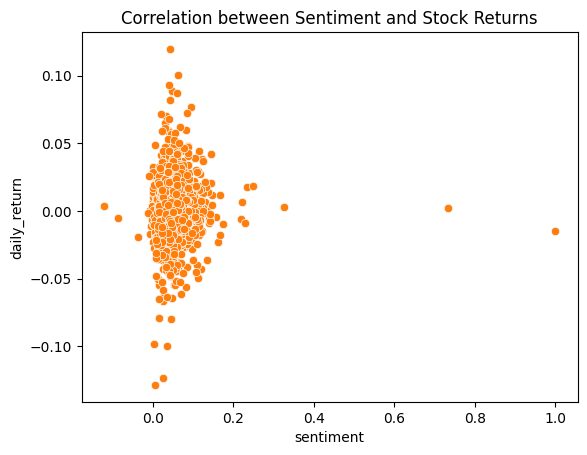

In [25]:
# 5. Visualize the Results

import seaborn as sns

sns.scatterplot(x=merged_df['sentiment'], y=merged_df['daily_return'])
# 5. Visualize the Results

import matplotlib.pyplot as plt

sns.scatterplot(x=merged_df['sentiment'], y=merged_df['daily_return'])
plt.title("Correlation between Sentiment and Stock Returns")
plt.show()
plt.show()
